In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2Model, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2",
                                   output_attentions=True)
model.eval()

print("Ready!")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 6470.33it/s]

Ready!


In [2]:
text = "The cat sat on the mat"
inputs = tokenizer(text, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

with torch.no_grad():
    outputs = model(**inputs)

# Attention weights — already softmax applied!
# Shape: [layers, heads, tokens, tokens]
attentions = outputs.attentions

print(f"Tokens: {tokens}")
print(f"Number of layers: {len(attentions)}")
print(f"Attention shape (layer 0): {attentions[0].shape}")

Tokens: ['The', 'Ġcat', 'Ġsat', 'Ġon', 'Ġthe', 'Ġmat']
Number of layers: 12
Attention shape (layer 0): torch.Size([1, 12, 6, 6])


Attention matrix (Layer 0, Head 0):
Rows = Query tokens (jo dekh raha hai)
Cols = Key tokens (kisko dekh raha hai)



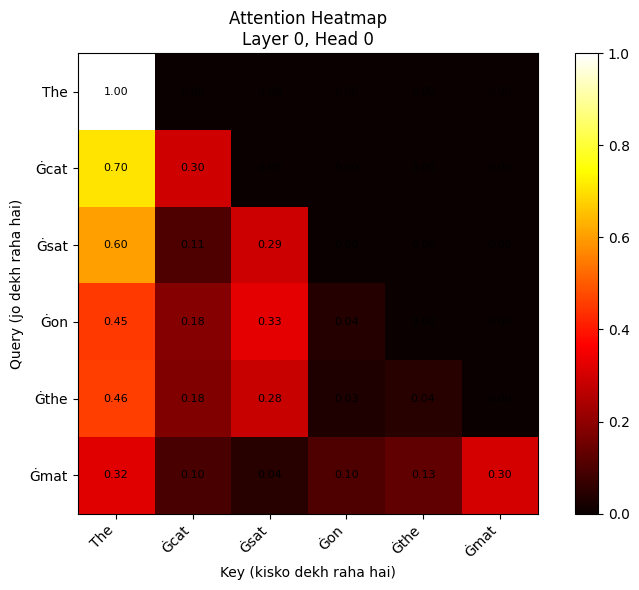

In [3]:

layer_idx = 0
head_idx  = 0

attn = attentions[layer_idx][0, head_idx].numpy()  # [6, 6]

print(f"Attention matrix (Layer {layer_idx}, Head {head_idx}):")
print(f"Rows = Query tokens (jo dekh raha hai)")
print(f"Cols = Key tokens (kisko dekh raha hai)\n")

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(attn, cmap="hot", vmin=0, vmax=1)
ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=45, ha="right")
ax.set_yticklabels(tokens)
ax.set_xlabel("Key (kisko dekh raha hai)")
ax.set_ylabel("Query (jo dekh raha hai)")
ax.set_title(f"Attention Heatmap\nLayer {layer_idx}, Head {head_idx}")


for i in range(len(tokens)):
    for j in range(len(tokens)):
        ax.text(j, i, f"{attn[i,j]:.2f}",
                ha="center", va="center", 
                color="black", fontsize=8)

plt.colorbar(im)
plt.tight_layout()
plt.show()

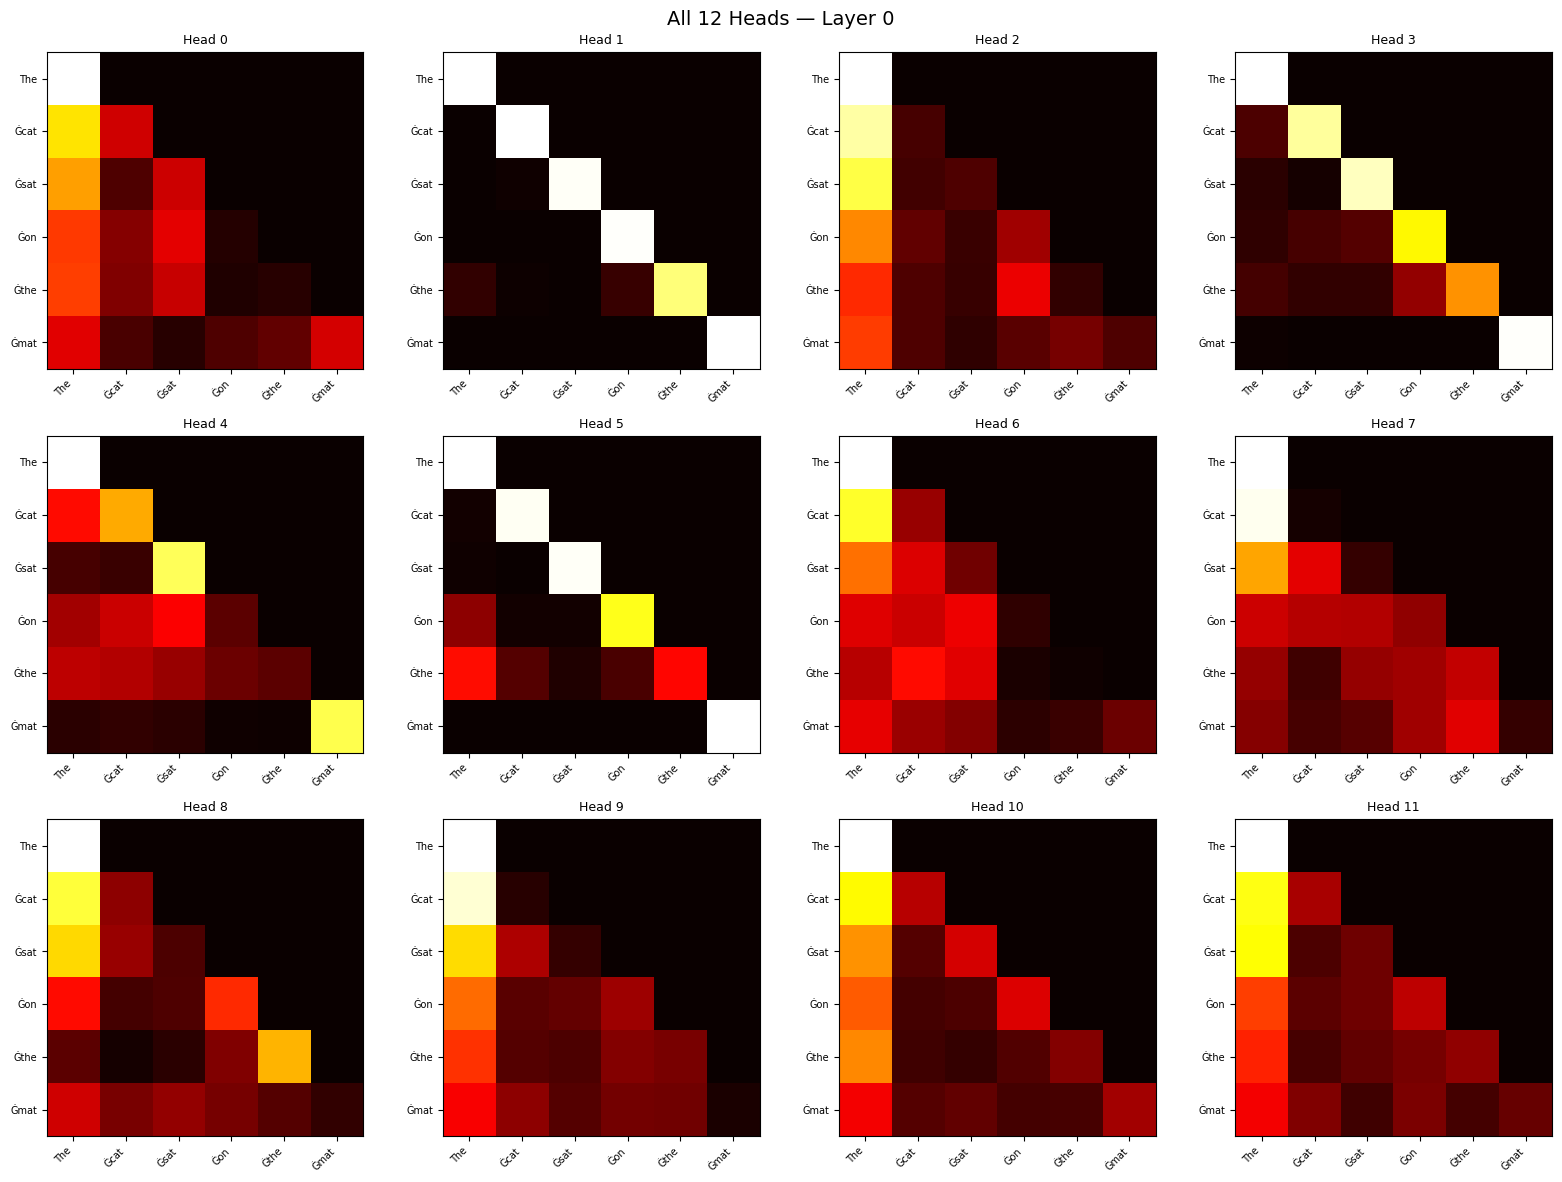

In [4]:

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for head_idx, ax in enumerate(axes.flat):
    attn = attentions[0][0, head_idx].numpy()
    
    im = ax.imshow(attn, cmap="hot", vmin=0, vmax=1)
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, 
                       ha="right", fontsize=7)
    ax.set_yticklabels(tokens, fontsize=7)
    ax.set_title(f"Head {head_idx}", fontsize=9)

fig.suptitle("All 12 Heads — Layer 0", fontsize=14)
plt.tight_layout()
plt.show()

* Attention scores = Q × Kᵀ — how much attention to give
* Softmax converts scores into probabilities
* Each head shows a different pattern
* The diagonal is strong — a token attends to itself
